# Phase 1 - neurone unique

Premier test : un seul neurone qui prédit si un point 2D est de classe 0 ou 1.
Pas d'entraînement ici, on fixe les poids à la main et on regarde ce que ça donne.

Formule du neurone : z = x1*w1 + x2*w2 + b, puis sigmoid(z) pour avoir une proba.

In [1]:
import numpy as np

X = np.array([
    [0.2, 0.1],
    [0.8, 0.9],
    [0.3, 0.7],
    [0.9, 0.2],
])
y = np.array([0, 1, 1, 0])

In [2]:
def sigmoid(x):
    # transforme n'importe quel nombre en valeur entre 0 et 1
    return 1 / (1 + np.exp(-x))

In [3]:
def forward(X, w, b):
    # somme pondérée puis activation
    z = np.dot(X, w) + b
    return sigmoid(z)

In [4]:
def compute_loss(y_true, y_pred):
    # Binary Cross-Entropy
    # clip pour éviter log(0) qui donne -inf
    y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

In [5]:
# poids fixés, pas encore d'entraînement
w = np.array([0.5, -0.3])
b = 0.1

y_pred = forward(X, w, b)
loss = compute_loss(y, y_pred)

print("Prédictions :", y_pred.round(3))
print("Étiquettes  :", y)
print(f"Loss BCE    : {loss:.4f}")

Prédictions : [0.542 0.557 0.51  0.62 ]
Étiquettes  : [0 1 1 0]
Loss BCE    : 0.7519


Les prédictions sont toutes autour de 0.5-0.6 : le neurone hésite sur tout, normal vu que les poids sont fixés au hasard. La loss est à ~0.75, c'est même pire qu'un modèle qui répondrait 0.5 partout (0.69). Il faudra la descente de gradient (phase 2) pour corriger les poids.

## Tests

**Cas limite : toutes les entrées à 0**

Si X = 0 alors z = b, donc le biais seul pilote la sortie. On doit avoir sigmoid(0.1) ≈ 0.525 partout.

In [6]:
X_zeros = np.zeros((4, 2))
pred_zeros = forward(X_zeros, w, b)

print("Prédictions :", pred_zeros.round(3))
print(f"sigmoid(b)  : {sigmoid(b):.3f}")
print(f"Loss        : {compute_loss(y, pred_zeros):.4f}")

Prédictions : [0.525 0.525 0.525 0.525]
sigmoid(b)  : 0.525
Loss        : 0.6944


**Scénario adversarial : poids et biais à 0**

Tout à zéro -> z = 0 -> sigmoid(0) = 0.5 partout, le réseau ne prédit rien.
La loss vaut -log(0.5) ≈ 0.693, c'est le pire point de départ possible (mais il apprendrait quand même avec une boucle d'entraînement).

In [7]:
w0 = np.zeros(2)
b0 = 0.0

pred_adv = forward(X, w0, b0)

print("Prédictions :", pred_adv.round(3))
print(f"Loss        : {compute_loss(y, pred_adv):.4f}")
print(f"-log(0.5)   : {-np.log(0.5):.4f}")

Prédictions : [0.5 0.5 0.5 0.5]
Loss        : 0.6931
-log(0.5)   : 0.6931


# Phase 2 - descente de gradient

On ajoute la boucle d'entraînement : à chaque epoch le neurone corrige ses poids dans la direction qui fait baisser la loss.

Pour un neurone sigmoid avec la BCE, le gradient se simplifie bien (chain rule) :
- dL/dw = (1/n) * X.T @ (y_pred - y)
- dL/db = moyenne(y_pred - y)

On réutilise sigmoid, forward et compute_loss de la phase 1. Cette fois les poids partent aléatoires (petits, seed fixée pour la reproductibilité) et c'est le gradient qui les corrige.

In [8]:
import matplotlib.pyplot as plt

np.random.seed(42)
w = np.random.randn(2) * 0.01   # petits poids aléatoires pour briser la symétrie
b = 0.0
learning_rate = 0.1
n_epochs = 200
losses = []

for epoch in range(n_epochs):
    # forward
    y_pred = forward(X, w, b)
    loss = compute_loss(y, y_pred)
    losses.append(loss)

    # gradient (simplification BCE + sigmoid)
    error = y_pred - y
    dw = X.T @ error / len(y)
    db = error.mean()

    # descente de gradient : un pas dans le sens opposé au gradient
    w -= learning_rate * dw
    b -= learning_rate * db

    if epoch % 40 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | w: {w.round(3)} | b: {b:.3f}")

print(f"Loss finale : {losses[-1]:.4f}")

Epoch   0 | Loss: 0.6934 | w: [0.005 0.015] | b: -0.000
Epoch  40 | Loss: 0.6074 | w: [-0.054  0.585] | b: -0.098
Epoch  80 | Loss: 0.5396 | w: [-0.149  1.07 ] | b: -0.257
Epoch 120 | Loss: 0.4828 | w: [-0.245  1.508] | b: -0.417
Epoch 160 | Loss: 0.4348 | w: [-0.335  1.909] | b: -0.565
Loss finale : 0.3951


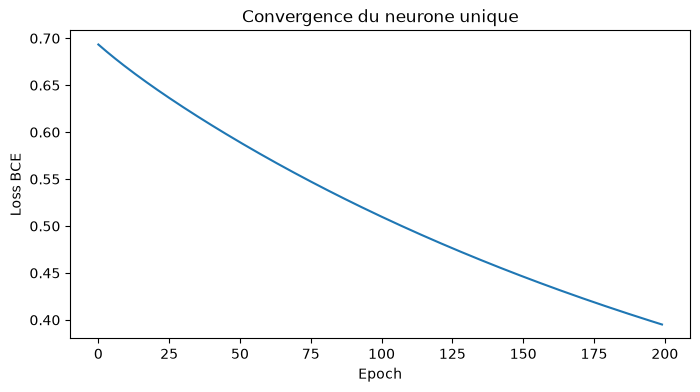

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss BCE")
plt.title("Convergence du neurone unique")
plt.savefig("phase2_loss_curve.png", dpi=100, bbox_inches='tight')
plt.show()

La loss part de 0.69 (poids quasi nuls -> prédictions ~0.5, cf phase 1) et descend régulièrement jusqu'à ~0.39.

Note : l'énoncé arrive à ~0.4 en 50 epochs seulement. En creusant, ses valeurs correspondent à un gradient sommé sur le batch (sans le 1/n), ce qui revient à un learning rate 4x plus grand. J'ai gardé la formule avec la moyenne (celle donnée dans le cours) donc il me faut ~200 epochs pour arriver au même point : même chemin, pas plus petits.

## Tests

Je remets la boucle dans une fonction pour tester d'autres learning rates sans copier-coller.

**Cas limite : learning_rate = 0** -> les poids ne bougent jamais, la loss non plus. Si un jour ma courbe ne descend pas, c'est la première chose à vérifier.

In [10]:
def train(lr, n_epochs=200):
    np.random.seed(42)
    w = np.random.randn(2) * 0.01
    b = 0.0
    losses = []
    for epoch in range(n_epochs):
        y_pred = forward(X, w, b)
        losses.append(compute_loss(y, y_pred))
        error = y_pred - y
        w -= lr * (X.T @ error) / len(y)
        b -= lr * error.mean()
    return losses

losses_0 = train(lr=0)
print(f"lr=0 : loss epoch 0 = {losses_0[0]:.4f} | loss epoch 199 = {losses_0[-1]:.4f}")

lr=0 : loss epoch 0 = 0.6934 | loss epoch 199 = 0.6934


**Scénario adversarial : learning_rate = 10**

Les pas sont énormes, on saute par-dessus le minimum au lieu de descendre tranquillement vers lui.

In [11]:
losses_10 = train(lr=10.0)
print("10 premières loss :", np.round(losses_10[:10], 4))
print(f"lr=10  : loss finale = {losses_10[-1]:.4f}")
print(f"lr=0.1 : loss finale = {losses[-1]:.4f}")

10 premières loss : [0.6934 0.5326 0.597  1.0224 0.7579 0.8841 0.2941 0.1665 0.0753 0.0695]
lr=10  : loss finale = 0.0060
lr=0.1 : loss finale = 0.3951


Avec lr=10 le début est chaotique : la loss fait 0.69 -> 0.53 -> 0.60 -> 1.02 -> 0.76... elle remonte au lieu de descendre, chaque pas saute par-dessus le minimum. Sur ce mini dataset de 4 points (séparable) elle finit quand même par tomber très bas, mais sur un vrai problème ce comportement diverge — c'est exactement ce qu'on verra en phase 7 sur MNIST. Le learning rate est le premier hyperparamètre à régler.

# Phase 3 - XOR : la limite du neurone unique

XOR : (0,0) -> 0, (1,1) -> 0, (0,1) -> 1, (1,0) -> 1. Ces 4 points ne sont pas linéairement séparables : aucune droite ne peut séparer les deux classes, donc le neurone unique des phases 1-2 ne peut pas résoudre ce problème. La solution : ajouter une couche cachée -> réseau 2-2-1 (2 entrées, 2 neurones cachés, 1 sortie).

La nouveauté c'est la backprop à travers 2 couches (chain rule) :
- couche 2 (sortie) : même simplification BCE+sigmoid qu'en phase 2, sauf que l'entrée de la couche c'est a1 (la sortie de la couche cachée)
- couche 1 (cachée) : on rétropropage l'erreur de sortie à travers W2, puis on multiplie par la dérivée de sigmoid : sigma'(z1) = a1 * (1 - a1)

In [12]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])

# architecture 2-2-1, initialisation aléatoire (seed 42, facteur 0.5)
np.random.seed(42)
W1 = np.random.randn(2, 2) * 0.5   # [2 entrées, 2 neurones cachés]
b1 = np.random.randn(2) * 0.5
W2 = np.random.randn(2, 1) * 0.5   # [2 cachés, 1 sortie]
b2 = np.random.randn(1) * 0.5

learning_rate = 0.5
n_epochs = 10000
losses_xor = []
n = len(y_xor)

for epoch in range(n_epochs):
    # forward : couche cachée puis couche de sortie
    z1 = X_xor @ W1 + b1
    a1 = sigmoid(z1)                  # [4, 2]
    z2 = a1 @ W2 + b2
    y_pred = sigmoid(z2).flatten()    # [4]

    losses_xor.append(compute_loss(y_xor, y_pred))

    # backprop couche 2 (même simplification BCE+sigmoid qu'en phase 2)
    error2 = (y_pred - y_xor).reshape(-1, 1)   # [4, 1]
    dW2 = a1.T @ error2 / n                    # [2, 1]
    db2 = error2.mean()

    # backprop couche 1 : erreur rétropropagée via W2, puis dérivée de sigmoid
    error1 = (error2 @ W2.T) * a1 * (1 - a1)   # [4, 2]
    dW1 = X_xor.T @ error1 / n                 # [2, 2]
    db1 = error1.mean(axis=0)                  # [2]

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if epoch % 2000 == 0:
        acc = np.mean((y_pred > 0.5) == y_xor)
        print(f"Epoch {epoch:5d} | Loss: {losses_xor[-1]:.4f} | Accuracy: {acc:.2%}")

print(f"Loss finale : {losses_xor[-1]:.4f}")
print(f"Accuracy finale : {np.mean((y_pred > 0.5) == y_xor):.2%}")

Epoch     0 | Loss: 0.7141 | Accuracy: 50.00%


Epoch  2000 | Loss: 0.0300 | Accuracy: 100.00%


Epoch  4000 | Loss: 0.0074 | Accuracy: 100.00%
Epoch  6000 | Loss: 0.0042 | Accuracy: 100.00%


Epoch  8000 | Loss: 0.0029 | Accuracy: 100.00%
Loss finale : 0.0022
Accuracy finale : 100.00%


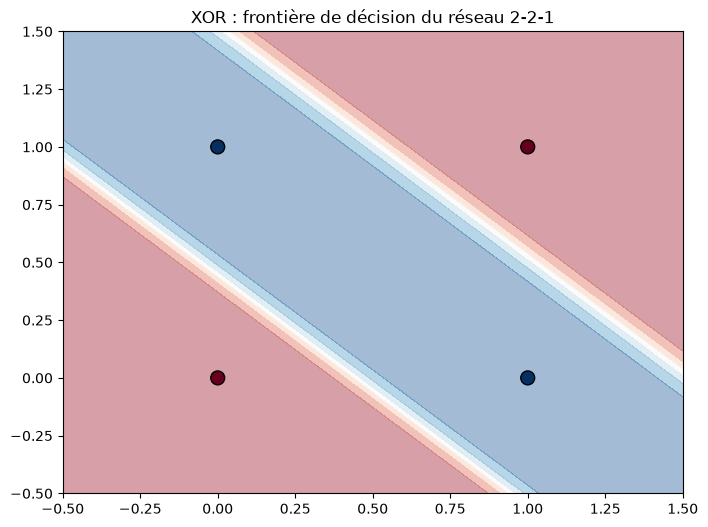

In [13]:
# frontière de décision : on évalue le réseau sur une grille de points
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
z1g = sigmoid(grid @ W1 + b1)
z2g = sigmoid(z1g @ W2 + b2).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, z2g, alpha=0.4, cmap='RdBu')
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, s=100, cmap='RdBu', edgecolors='k')
plt.title("XOR : frontière de décision du réseau 2-2-1")
plt.savefig("phase3_xor_boundary.png", dpi=100, bbox_inches='tight')
plt.show()

100% d'accuracy, loss quasi nulle, et la frontière n'est pas une droite : la zone de la classe 1 passe entre (0,0) et (1,1). Aucune droite ne pourrait faire cette séparation, c'est la couche cachée qui rend ça possible : chaque neurone caché apprend sa propre droite, et la couche de sortie combine les deux.

## Tests

Même principe qu'en phase 2, je remets l'entraînement dans une fonction pour tester des variantes.

**Biais initialisés à zéro : piégé dans un minimum local**

En codant cette phase j'ai d'abord initialisé les biais à zéro (comme en phase 2), et avec cette seed le réseau reste bloqué à 50% : la loss se fige vers 0.35 et n'en bouge plus, même avec 40 000 epochs. Ce n'est pas un problème de vitesse, c'est un minimum local. D'où l'initialisation aléatoire des biais aussi.

In [14]:
def train_xor(n_hidden, X, y, lr=0.5, n_epochs=10000, zero_bias=False):
    np.random.seed(42)
    W1 = np.random.randn(2, n_hidden) * 0.5
    b1 = np.zeros(n_hidden) if zero_bias else np.random.randn(n_hidden) * 0.5
    W2 = np.random.randn(n_hidden, 1) * 0.5
    b2 = np.zeros(1) if zero_bias else np.random.randn(1) * 0.5
    n = len(y)
    for epoch in range(n_epochs):
        a1 = sigmoid(X @ W1 + b1)
        y_pred = sigmoid(a1 @ W2 + b2).flatten()
        error2 = (y_pred - y).reshape(-1, 1)
        error1 = (error2 @ W2.T) * a1 * (1 - a1)
        W2 -= lr * a1.T @ error2 / n
        b2 -= lr * error2.mean()
        W1 -= lr * X.T @ error1 / n
        b1 -= lr * error1.mean(axis=0)
    return compute_loss(y, y_pred), np.mean((y_pred > 0.5) == y)

loss_zb, acc_zb = train_xor(2, X_xor, y_xor, zero_bias=True)
print(f"biais à zéro : loss = {loss_zb:.4f} | accuracy = {acc_zb:.0%}")

biais à zéro : loss = 0.3480 | accuracy = 50%


**Cas limite : un seul neurone caché (2-1-1)**

Avec 1 seul neurone caché, le réseau n'a qu'une seule représentation intermédiaire : une seule "droite" à combiner, pas assez pour plier l'espace autour des 4 points de XOR.

In [15]:
loss_211, acc_211 = train_xor(1, X_xor, y_xor)
print(f"réseau 2-1-1 : loss = {loss_211:.4f} | accuracy = {acc_211:.0%}")

réseau 2-1-1 : loss = 0.4787 | accuracy = 75%


Il plafonne à 75% : 3 points sur 4 bien classés, le dernier est sacrifié. Il faut au moins 2 neurones cachés pour XOR.

**Scénario adversarial : 5% de bruit sur les coordonnées**

In [16]:
np.random.seed(7)
X_bruit = X_xor + np.random.randn(*X_xor.shape) * 0.05

loss_n, acc_n = train_xor(2, X_bruit, y_xor)
print(f"bruit 5% : loss = {loss_n:.4f} | accuracy = {acc_n:.0%}")

bruit 5% : loss = 0.0022 | accuracy = 100%


Le petit bruit ne casse pas la convergence : toujours 100%. Les 4 points restent bien séparés dans leurs coins, la frontière a juste un peu bougé. Un bruit plus fort ou une mauvaise seed pourrait par contre suffire à perturber l'entraînement sur si peu de points — 4 exemples c'est très peu de marge.

# Phase 4 - spirale 2D

Dataset beaucoup plus dur : deux spirales entrelacées (400 points). Il faut un réseau plus gros : 2-64-64-1, soit deux couches cachées de 64 neurones.

Deux nouveautés :
- **ReLU** à la place de sigmoid dans les couches cachées : relu(x) = max(0, x). Gradient constant (1) pour x > 0 donc pas de saturation, l'entraînement va plus vite. Sa dérivée : 1 si x > 0, sinon 0.
- **Initialisation He**, adaptée à ReLU : std = sqrt(2 / n_entrées de la couche), biais à zéro.

Note : même histoire qu'en phase 2, le lr=0.01 de l'énoncé suppose un gradient sommé. Avec le gradient moyenné (n=400 ici, le facteur est énorme), lr=0.01 laisse le réseau à ~70% après 2000 epochs. Je prends lr=0.5.

In [17]:
def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    # dérivée de relu : 1 si x > 0, sinon 0
    return (x > 0).astype(float)

def generate_spiral(n_points=200, noise=0.1, seed=42):
    """Génère deux spirales entrelacées : classe 0 et classe 1."""
    np.random.seed(seed)
    n = n_points // 2
    theta0 = np.linspace(0, 4 * np.pi, n) + np.random.randn(n) * noise
    theta1 = np.linspace(0, 4 * np.pi, n) + np.random.randn(n) * noise + np.pi
    r = np.linspace(0.1, 1.0, n)
    X0 = np.c_[r * np.cos(theta0), r * np.sin(theta0)]
    X1 = np.c_[r * np.cos(theta1), r * np.sin(theta1)]
    X = np.vstack([X0, X1])
    y = np.hstack([np.zeros(n), np.ones(n)])
    return X, y

X_sp, y_sp = generate_spiral(n_points=400, noise=0.15)
print(f"X : {X_sp.shape} | y : {y_sp.shape}")

X : (400, 2) | y : (400,)


In [18]:
# architecture 2-64-64-1, initialisation He (std = sqrt(2 / n_entrées)), biais à zéro
np.random.seed(42)
W1 = np.random.randn(2, 64) * np.sqrt(2 / 2)
b1 = np.zeros(64)
W2 = np.random.randn(64, 64) * np.sqrt(2 / 64)
b2 = np.zeros(64)
W3 = np.random.randn(64, 1) * np.sqrt(2 / 64)
b3 = np.zeros(1)

lr = 0.5
n_epochs = 2000
losses_sp = []
n = len(y_sp)

for epoch in range(n_epochs):
    # forward - 3 couches
    z1 = X_sp @ W1 + b1
    a1 = relu(z1)                     # [400, 64]
    z2 = a1 @ W2 + b2
    a2 = relu(z2)                     # [400, 64]
    z3 = a2 @ W3 + b3
    y_pred = sigmoid(z3).flatten()    # [400]

    losses_sp.append(compute_loss(y_sp, y_pred))

    # backward - on remonte couche par couche (même schéma qu'en phase 3)
    err3 = (y_pred - y_sp).reshape(-1, 1)      # [400, 1]
    dW3 = a2.T @ err3 / n
    db3 = err3.mean()

    err2 = (err3 @ W3.T) * relu_grad(z2)       # [400, 64]
    dW2 = a1.T @ err2 / n
    db2 = err2.mean(axis=0)

    err1 = (err2 @ W2.T) * relu_grad(z1)       # [400, 64]
    dW1 = X_sp.T @ err1 / n
    db1 = err1.mean(axis=0)

    W3 -= lr * dW3; b3 -= lr * db3
    W2 -= lr * dW2; b2 -= lr * db2
    W1 -= lr * dW1; b1 -= lr * db1

    if epoch % 500 == 0:
        acc = np.mean((y_pred > 0.5) == y_sp)
        print(f"Epoch {epoch:4d} | Loss: {losses_sp[-1]:.4f} | Accuracy: {acc:.2%}")

print(f"Loss finale : {losses_sp[-1]:.4f}")
print(f"Accuracy finale : {np.mean((y_pred > 0.5) == y_sp):.2%}")

Epoch    0 | Loss: 0.7224 | Accuracy: 50.00%


Epoch  500 | Loss: 0.5704 | Accuracy: 65.50%


Epoch 1000 | Loss: 0.2838 | Accuracy: 86.75%


Epoch 1500 | Loss: 0.0425 | Accuracy: 99.75%


Loss finale : 0.0102
Accuracy finale : 100.00%


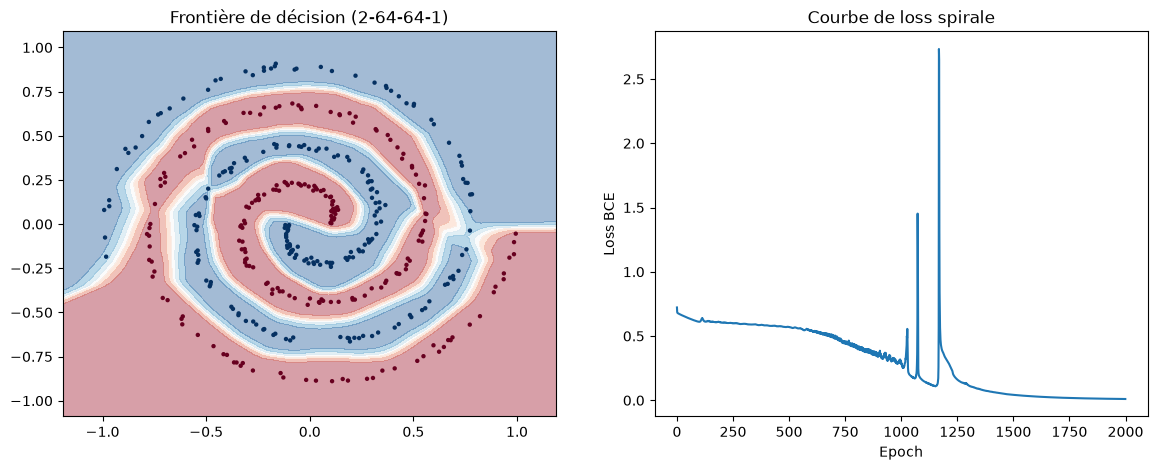

In [19]:
# frontière de décision + courbe de loss côte à côte
h = 0.02
xx, yy = np.meshgrid(np.arange(X_sp[:, 0].min() - 0.2, X_sp[:, 0].max() + 0.2, h),
                     np.arange(X_sp[:, 1].min() - 0.2, X_sp[:, 1].max() + 0.2, h))
grid = np.c_[xx.ravel(), yy.ravel()]
a1g = relu(grid @ W1 + b1)
a2g = relu(a1g @ W2 + b2)
zg = sigmoid(a2g @ W3 + b3).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].contourf(xx, yy, zg, alpha=0.4, cmap='RdBu')
axes[0].scatter(X_sp[:, 0], X_sp[:, 1], c=y_sp, cmap='RdBu', s=10, edgecolors='none')
axes[0].set_title("Frontière de décision (2-64-64-1)")
axes[1].plot(losses_sp)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss BCE")
axes[1].set_title("Courbe de loss spirale")
plt.savefig("phase4_spirale.png", dpi=100, bbox_inches='tight')
plt.show()

100% d'accuracy et la frontière suit vraiment la forme des spirales, elle s'enroule avec les données. C'est la version puissance 10 de XOR : 128 neurones cachés au lieu de 2, et le réseau peut plier l'espace autant qu'il faut.

Sur la courbe de loss on voit deux gros pics vers les epochs 1000-1200 : avec lr=0.5 certains pas sont trop grands et font brièvement exploser la loss (même phénomène que le lr=10 de la phase 2, en version passagère). Le réseau retombe juste après et finit de converger proprement.

## Tests

Comme d'habitude, une fonction pour les variantes (mêmes 3 couches, tailles paramétrables).

**Cas limite : réseau trop petit (underfitting délibéré)**

L'énoncé propose 2-2-1 ; avec mon code 3 couches je teste l'équivalent 2-2-2-1 : deux couches cachées de 2 neurones, même esprit.

In [20]:
def train_spirale(h1, h2, X, y, lr=0.5, n_epochs=2000):
    np.random.seed(42)
    W1 = np.random.randn(2, h1) * np.sqrt(2 / 2);   b1 = np.zeros(h1)
    W2 = np.random.randn(h1, h2) * np.sqrt(2 / h1); b2 = np.zeros(h2)
    W3 = np.random.randn(h2, 1) * np.sqrt(2 / h2);  b3 = np.zeros(1)
    n = len(y)
    for epoch in range(n_epochs):
        z1 = X @ W1 + b1; a1 = relu(z1)
        z2 = a1 @ W2 + b2; a2 = relu(z2)
        y_pred = sigmoid(a2 @ W3 + b3).flatten()
        err3 = (y_pred - y).reshape(-1, 1)
        err2 = (err3 @ W3.T) * relu_grad(z2)
        err1 = (err2 @ W2.T) * relu_grad(z1)
        W3 -= lr * a2.T @ err3 / n; b3 -= lr * err3.mean()
        W2 -= lr * a1.T @ err2 / n; b2 -= lr * err2.mean(axis=0)
        W1 -= lr * X.T @ err1 / n;  b1 -= lr * err1.mean(axis=0)
    return compute_loss(y, y_pred), np.mean((y_pred > 0.5) == y)

loss_petit, acc_petit = train_spirale(2, 2, X_sp, y_sp)
print(f"réseau 2-2-2-1   : loss = {loss_petit:.4f} | accuracy = {acc_petit:.1%}")
print(f"réseau 2-64-64-1 : loss = {losses_sp[-1]:.4f} | accuracy = {np.mean((sigmoid(relu(relu(X_sp @ W1 + b1) @ W2 + b2) @ W3 + b3).flatten() > 0.5) == y_sp):.1%}")

réseau 2-2-2-1   : loss = 0.6785 | accuracy = 57.0%
réseau 2-64-64-1 : loss = 0.0102 | accuracy = 100.0%


57% contre 100% : avec 2 neurones par couche le réseau n'a pas la capacité de suivre les spirales, il sous-fitte. La taille du réseau doit être à la hauteur de la complexité du problème.

**Scénario adversarial : bruit fort (noise=0.5 au lieu de 0.15)**

In [21]:
X_sp_bruit, y_sp_bruit = generate_spiral(n_points=400, noise=0.5)

loss_b, acc_b = train_spirale(64, 64, X_sp_bruit, y_sp_bruit)
print(f"noise=0.5  : loss = {loss_b:.4f} | accuracy = {acc_b:.1%}")
print(f"noise=0.15 : loss = {losses_sp[-1]:.4f} | accuracy = 100.0%")

noise=0.5  : loss = 0.0544 | accuracy = 98.5%
noise=0.15 : loss = 0.0102 | accuracy = 100.0%


Même avec un bruit fort le réseau tient 98.5% : les spirales bruitées se chevauchent par endroits et il colle quand même aux points. C'est à double tranchant : un gros réseau a assez de capacité pour apprendre le bruit lui-même (la frontière devient irrégulière, taillée sur mesure pour les points aberrants). Sur les données d'entraînement ça fait un beau score, mais sur de nouveaux points ça généraliserait moins bien - c'est l'overfitting, le sujet du J2.

# Phase 5 - le même travail en Keras, sur MNIST

Changement d'échelle et d'outil. MNIST : 70 000 images de chiffres manuscrits 28x28 (60k train / 10k test), 10 classes. Chaque image est aplatie en un vecteur de 784 pixels, normalisés entre 0 et 1.

Tout ce qu'on a codé à la main dans les phases 1-4 (forward, backprop, boucle d'entraînement), Keras le fait tout seul : on décrit le modèle couche par couche, model.compile choisit la loss et l'optimiseur, model.fit fait la boucle.

Architecture : Dense(128, relu) -> Dense(64, relu) -> Dense(10, softmax).
- softmax en sortie : 10 neurones, une proba par chiffre, somme = 1 (contrairement à sigmoid, les classes sont en compétition)
- loss sparse_categorical_crossentropy : la version multiclass de notre BCE, "sparse" = étiquettes entières (0-9), pas besoin de one-hot
- optimiseur Adam : descente de gradient avec mémoire des gradients passés, converge plus vite que notre descente "pas fixe"

In [22]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'   # calmer les logs tensorflow
import time
import tensorflow as tf
from tensorflow import keras

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# flatten 28x28 -> 784, normaliser 0-255 -> 0-1
X_train = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test = X_test.reshape(-1, 784).astype('float32') / 255.0

print(f"Train : {X_train.shape} | Test : {X_test.shape}")
print(f"Classes uniques : {np.unique(y_train)}")

I0000 00:00:1783953385.947305     562 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783953385.948021     562 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1783953387.992304     562 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783953387.993163     562 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Train : (60000, 784) | Test : (10000, 784)
Classes uniques : [0 1 2 3 4 5 6 7 8 9]


In [23]:
def build_model():
    tf.random.set_seed(42)   # même initialisation à chaque appel, pour comparer
    model = keras.Sequential([
        keras.Input(shape=(784,)),   # keras 3 préfère Input() à input_shape=
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(10, activation='softmax'),
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_model()
model.summary()

E0000 00:00:1783953388.964146     562 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
start = time.time()
history = model.fit(X_train, y_train, epochs=5, batch_size=64,
                    validation_split=0.1, verbose=2)
elapsed = time.time() - start

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTemps d'entraînement : {elapsed:.1f}s")
print(f"Test accuracy : {test_acc:.4f}")
print(f"Test loss     : {test_loss:.4f}")

Epoch 1/5


844/844 - 8s - 9ms/step - accuracy: 0.9168 - loss: 0.2874 - val_accuracy: 0.9612 - val_loss: 0.1320


Epoch 2/5


844/844 - 6s - 7ms/step - accuracy: 0.9649 - loss: 0.1185 - val_accuracy: 0.9668 - val_loss: 0.1067


Epoch 3/5


...

Epoch 4/5


844/844 - 6s - 7ms/step - accuracy: 0.9826 - loss: 0.0595 - val_accuracy: 0.9713 - val_loss: 0.0993


Epoch 5/5


844/844 - 6s - 7ms/step - accuracy: 0.9872 - loss: 0.0444 - val_accuracy: 0.9720 - val_loss: 0.1011



Temps d'entraînement : 32.6s
Test accuracy : 0.9742
Test loss     : 0.0882


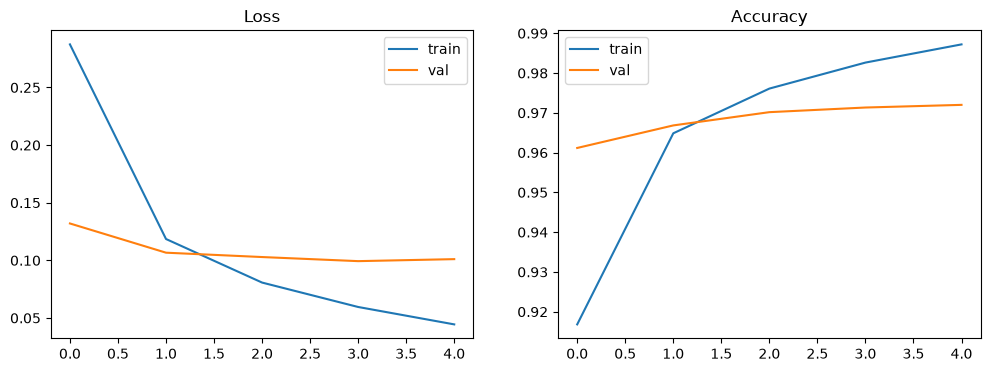

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title("Accuracy"); axes[1].legend()
plt.savefig("phase5_mnist_curves.png", dpi=100, bbox_inches='tight')
plt.show()

97.5% sur le test en 5 epochs et ~45 secondes sur CPU. Notre code numpy des phases 1-4 aurait besoin de beaucoup plus d'epochs (et de débogage de shapes) pour approcher ça sur 60 000 images.

La comparaison à retenir :
- from scratch : ~80 lignes pour 3 couches, backprop à la main, une erreur de dimension = crash mystérieux
- Keras : ~15 lignes, gradients automatiques, messages d'erreur clairs avec les shapes

Keras fait exactement la même chose que notre code (forward, backprop, mise à jour), mais optimisé en C, et on choisit l'architecture au lieu de la coder.

## Tests

**Cas limite : epochs=0**

Qu'est-ce que Keras fait si on ne lui donne aucune epoch ?

In [26]:
model_0 = build_model()
h0 = model_0.fit(X_train, y_train, epochs=0, verbose=0)
print("Pas d'erreur levée. history =", h0.history)

Pas d'erreur levée. history = {}


Keras ne lève pas d'erreur : il retourne juste un historique vide ({}). Le modèle n'a jamais vu les données, il en reste à son initialisation aléatoire (~10% d'accuracy, une chance sur 10).

**Scénario adversarial : batch_size=1 (SGD pur)**

On met à jour les poids après chaque exemple au lieu de tous les 64 exemples. Pour ne pas y passer l'après-midi, je compare sur un sous-ensemble de 10 000 images et 1 epoch chacun - c'est le temps par epoch qui compte.

In [27]:
Xs, ys = X_train[:10000], y_train[:10000]

m64 = build_model()
t = time.time()
m64.fit(Xs, ys, epochs=1, batch_size=64, verbose=0)
t64 = time.time() - t

m1 = build_model()
t = time.time()
m1.fit(Xs, ys, epochs=1, batch_size=1, verbose=0)
t1 = time.time() - t

print(f"batch=64 : {t64:.1f}s | batch=1 : {t1:.1f}s")
print(f"batch=1 est {t1/t64:.0f}x plus lent par epoch")

batch=64 : 2.6s | batch=1 : 67.6s
batch=1 est 26x plus lent par epoch


batch=1 est ~27x plus lent : 10 000 mises à jour au lieu de 157, et surtout plus aucune vectorisation - on perd tout l'intérêt du calcul matriciel vu en phase 1. Sur les 60 000 images et 5 epochs, ça ferait plus d'une demi-heure au lieu de ~45 secondes. En plus d'être lent, le gradient calculé sur 1 seul exemple est très bruité et la loss oscille.

Le mini-batch (32-128) est le compromis standard : assez gros pour vectoriser et lisser le gradient, assez petit pour garder un peu de bruit utile (qui aide à généraliser) et ne pas saturer la mémoire.

# Phase 6 - comparer les fonctions d'activation

Même architecture, même optimiseur (Adam lr=0.001), même dataset, même seed, 10 epochs : on ne change que l'activation des couches cachées. sigmoid vs tanh vs relu.

Ce qu'on attend d'après la théorie : sigmoid sature (gradient quasi nul quand |x| est grand -> vanishing gradient), tanh sature aussi mais est centrée sur 0 (gradients mieux répartis), relu ne sature pas pour x > 0 -> convergence plus rapide.

In [28]:
def build_mnist(activation):
    tf.random.set_seed(42)   # même initialisation pour une comparaison équitable
    m = keras.Sequential([
        keras.Input(shape=(784,)),
        keras.layers.Dense(128, activation=activation),
        keras.layers.Dense(64, activation=activation),
        keras.layers.Dense(10, activation='softmax'),
    ])
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m

def run_activation(activation):
    m = build_mnist(activation)
    t = time.time()
    h = m.fit(X_train, y_train, epochs=10, batch_size=64,
              validation_split=0.1, verbose=0)
    train_time = time.time() - t
    test_loss, test_acc = m.evaluate(X_test, y_test, verbose=0)
    val_losses = h.history['val_loss']
    # première epoch où la val_loss passe sous 0.1 (ou N/A si jamais)
    conv = next((i + 1 for i, v in enumerate(val_losses) if v < 0.1), "N/A")
    return {'activation': str(activation), 'val_loss_final': val_losses[-1],
            'test_accuracy': test_acc, 'convergence_epoch': conv,
            'train_time_s': train_time, 'val_losses': val_losses}

activations = ['sigmoid', 'tanh', 'relu']
results = []
histories = {}
for act in activations:
    r = run_activation(act)
    results.append(r)
    histories[act] = r['val_losses']
    print(f"{act:8s} : fini en {r['train_time_s']:.0f}s")

sigmoid  : fini en 89s


tanh     : fini en 115s


relu     : fini en 125s


In [29]:
print(f"{'Activation':10s} | {'Val loss (ep.10)':16s} | {'Test accuracy':13s} | {'Epoch < 0.1':11s} | {'Temps (s)':9s}")
print("-" * 74)
for r in results:
    print(f"{r['activation']:10s} | {r['val_loss_final']:16.4f} | {r['test_accuracy']:13.4f} | {str(r['convergence_epoch']):11s} | {r['train_time_s']:9.0f}")

Activation | Val loss (ep.10) | Test accuracy | Epoch < 0.1 | Temps (s)
--------------------------------------------------------------------------
sigmoid    |           0.0728 |        0.9753 | 5           |        89
tanh       |           0.0887 |        0.9750 | 3           |       115
relu       |           0.1007 |        0.9762 | 2           |       125


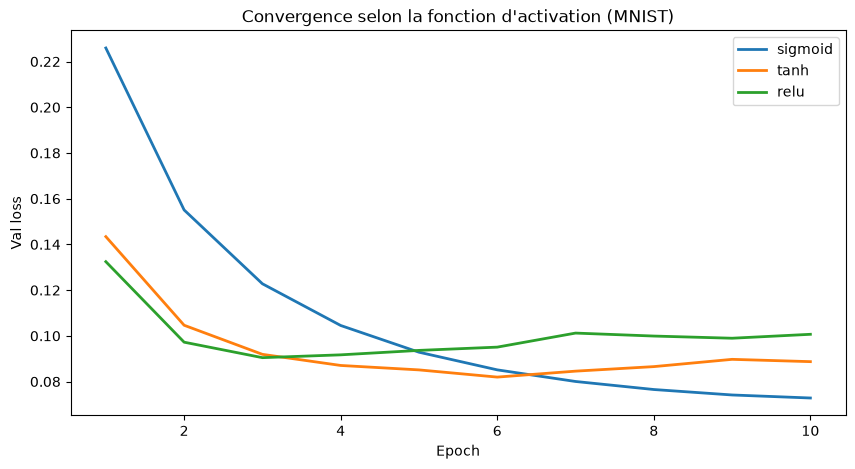

In [30]:
plt.figure(figsize=(10, 5))
for act, vl in histories.items():
    plt.plot(range(1, 11), vl, label=act, linewidth=2)
plt.xlabel("Epoch"); plt.ylabel("Val loss")
plt.title("Convergence selon la fonction d'activation (MNIST)")
plt.legend()
plt.savefig("phase6_activations_curve.png", dpi=100, bbox_inches='tight')
plt.show()

La vitesse de convergence se lit sur la colonne "Epoch < 0.1" : relu passe sous 0.1 de val_loss dès l'epoch 2, tanh à l'epoch 3, sigmoid attend l'epoch 5. C'est le vanishing gradient en pratique, bien visible sur les premières epochs de la courbe : sigmoid part de beaucoup plus haut et descend lentement.

Détail intéressant qui ne colle pas à l'intuition : à l'epoch 10, c'est sigmoid qui a la meilleure val_loss (0.073 contre 0.101 pour relu). L'explication est sur la courbe : relu a convergé si vite qu'il touche son minimum vers l'epoch 3-5 puis sa val_loss remonte doucement (début d'overfitting), pendant que sigmoid, plus lent, est encore en train de descendre. Vitesse de convergence et score à une epoch donnée sont deux choses différentes. Sur un réseau profond, sigmoid ne rattraperait jamais : ici on n'a que 2 couches cachées, le vanishing gradient reste supportable.

J'ai revérifié ce schéma avec 3 autres seeds (0, 7, 123) : identique à chaque fois — relu sous 0.1 à l'epoch 2 avec un minimum vers l'epoch 4-5 puis remontée, sigmoid sous 0.1 à l'epoch 5 et minimum à l'epoch 10. Ce n'est donc pas un accident de l'initialisation.

## Tests

**Cas limite : aucune activation (couches linéaires)**

Sans argument activation, Keras applique une activation linéaire. On retombe sur le problème vu en théorie : empiler des couches linéaires = une seule couche linéaire déguisée. Les 128 et 64 neurones cachés ne servent à rien.

In [31]:
r_lin = run_activation(None)
print(f"linear : val_loss = {r_lin['val_loss_final']:.4f} | test_acc = {r_lin['test_accuracy']:.4f}")
print(f"relu   : val_loss = {results[2]['val_loss_final']:.4f} | test_acc = {results[2]['test_accuracy']:.4f}")

linear : val_loss = 0.2522 | test_acc = 0.9177
relu   : val_loss = 0.1007 | test_acc = 0.9762


Le modèle linéaire plafonne bien en dessous : c'est une régression logistique multiclass déguisée, incapable de capturer les patterns non-linéaires des pixels. La preuve par l'exemple de la section théorie.

**Scénario adversarial : softmax partout (couches cachées incluses)**

Softmax en couche cachée force les 128 sorties de la couche à sommer à 1 : les neurones se battent entre eux au lieu de détecter chacun leur pattern, et les activations deviennent minuscules (~1/128 en moyenne).

In [32]:
r_soft = run_activation('softmax')
print(f"softmax partout : val_loss = {r_soft['val_loss_final']:.4f} | test_acc = {r_soft['test_accuracy']:.4f}")
print(f"relu            : val_loss = {results[2]['val_loss_final']:.4f} | test_acc = {results[2]['test_accuracy']:.4f}")

softmax partout : val_loss = 0.2452 | test_acc = 0.9243
relu            : val_loss = 0.1007 | test_acc = 0.9762


La dégradation est nette. Softmax est faite pour produire une distribution de probabilités en sortie, pas pour transmettre de l'information entre couches : la contrainte somme = 1 écrase les activations et couple tous les neurones entre eux.

Bilan de la phase : relu par défaut dans les couches cachées, softmax uniquement en sortie multiclass, sigmoid uniquement en sortie binaire. Exactement le tableau de choix du cours, vérifié expérimentalement.